# Load QICK

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_9d15d795906340efa5b6699bc4af6d6f@192.168.10.82:41515
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

# Qubit Setting

In [150]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q3"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

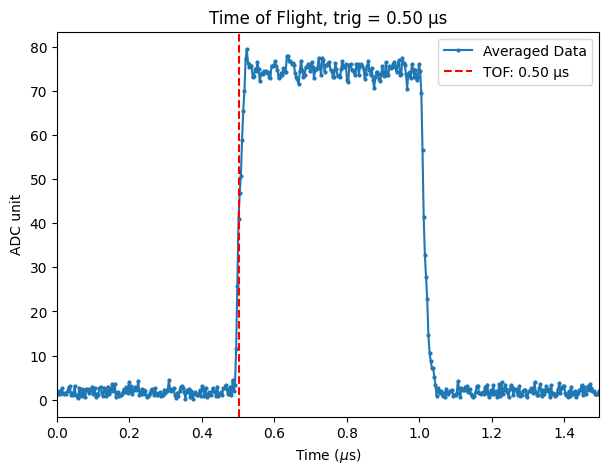

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s001_tof_Q1_003


In [5]:
from qick_workspace.newscrip.s001_time_of_flight import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        "res_freq_ge": 6862,
        "ro_length": 1.5,
        "res_length": 0.5,
        "res_gain_ge": 1,
        "res_ch": 0,
    }
)

tof = TOF(soc, soccfg, run_cfg)
tof.run(100)
tof.saveLabber(qubit)


In [3]:
config_all.update("trig_time", 0.49, q_index=qubit)

# YOKO Setting

In [ ]:
# from qick_workspace.tools.YOKOGS200 import YOKOGS200
# import pyvisa

# rm = pyvisa.ResourceManager()
# yoko_connect = "USB0::0x0B21::0x0039::90ZB35281::INSTR"
# yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
# yoko.OutputOff()

## Current mode

In [8]:
# yoko.SetMode("current")
# yokocurrent = 1 * 1e-3
# yoko.SetCurrent(yokocurrent)
# yoko.GetValue()

## Voltage mode

In [ ]:
# yoko.SetMode("voltage")
# yoko_value = -12.6
# yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# print(yoko.GetValue())
# yoko_value = yoko.GetValue()

# GE State

## Resonator OneTone

{'Fres(GHz)': np.float64(6.8857),
 'Qi': -3179,
 'Ql': 196,
 'absQc': 185,
 'κ(MHz)': np.float64(35.14)}


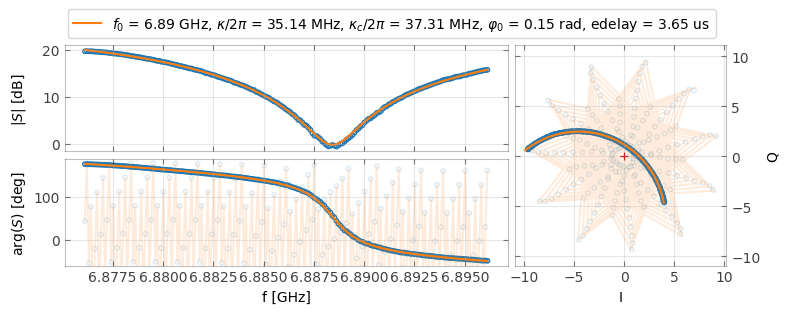

In [144]:
from qick_workspace.newscrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10 # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]

# START_FREQ = 6500 # [MHz]
# STOP_FREQ = 7000  # [MHz]


STEPS = 201

config_all.update("res.res_gain_ge", 0.15, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(soc, soccfg, run_cfg)
fres = onetone.run(py_avg=10, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

In [59]:
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s002_onetone_ge_Q3_001


## OneTone PunchOut

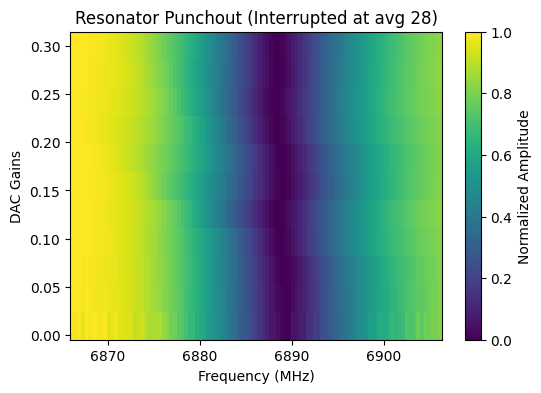

Experiment interrupted at 28 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s002b_res_ge_punchout_Q4_003


In [137]:
from qick_workspace.newscrip.s002b_res_punchout_ge import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]
STEPS_freq = 101

START_gain = 0.01
STOP_gain = 0.3
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
    ]
)
punchout = Punchout(soc, soccfg, run_cfg)
punchout.run(py_avg=50, show_final_plot=True)
punchout.saveLabber(qubit, config_all=config_all)

In [46]:
config_all.update("res.res_freq_ge", 6735, q_index=qubit)

## Qubit Spectrum ge

Experiment interrupted at 27 averages. Fit is based on partial data.


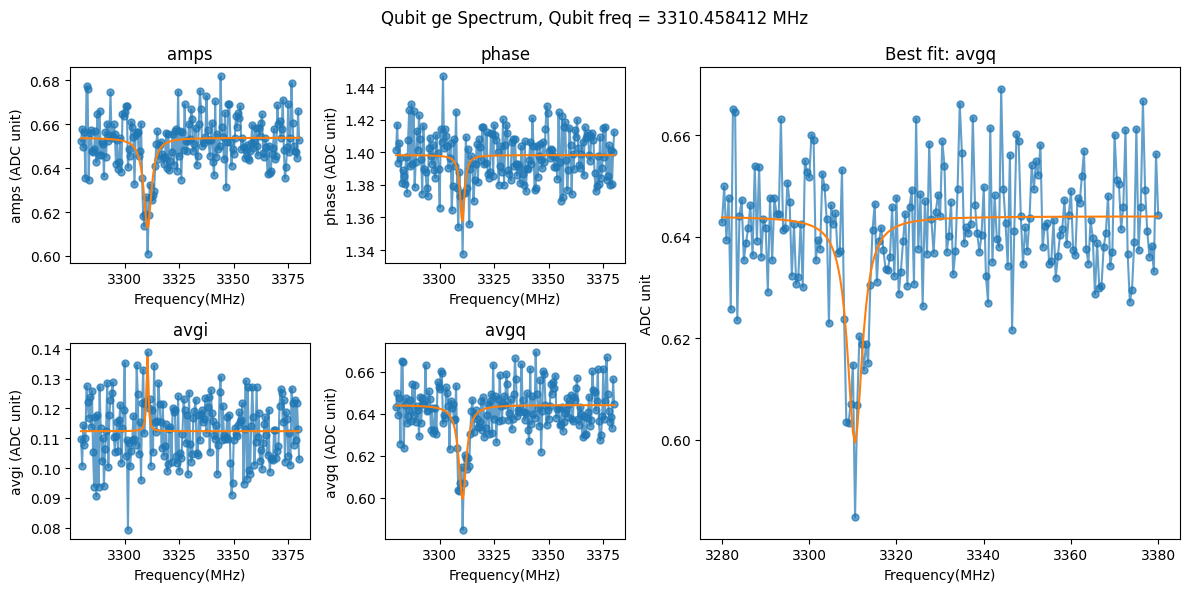

In [138]:
from qick_workspace.newscrip.s003_qubit_spec_ge import QubitSpec

center = 3330
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.1),
        ("qb_flat_top_length_ge", 0.1),
        ("relax_delay", 1),
        ("nqz_qb", 1),


    ]
)

spectrum_ge = QubitSpec(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(500)
config_all.update("qb.qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb.qb_mixer", f_ge, q_index=qubit)


In [139]:
spectrum_ge.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s003_qubit_spec_ge_Q4_001


## Time Rabi ge

Experiment interrupted at 40 averages. Fit is based on partial data.


(np.float64(0.009813125544248359), np.float64(0.006373855348444049))

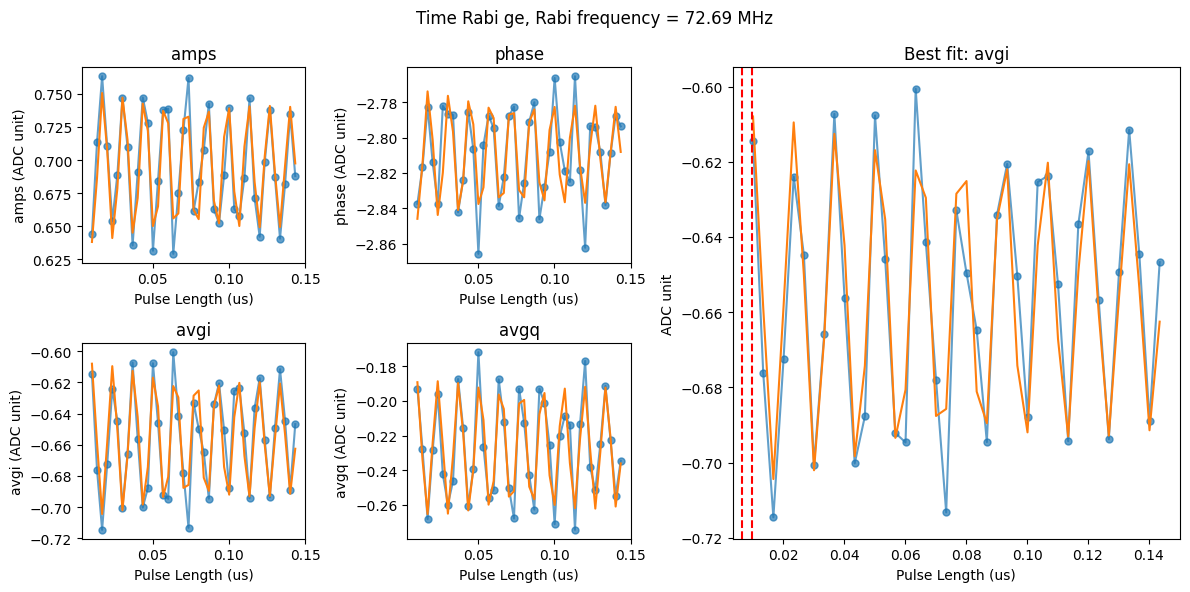

In [132]:
from qick_workspace.newscrip.s004_time_rabi_ge import TimeRabi



config_all.update("qb.sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.9),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.2)),
        ("steps", 41)
    ]
)

Trabi = TimeRabi(soc, soccfg, run_cfg)
Trabi.run(100)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ge

Experiment interrupted at 18 averages. Fit is based on partial data.


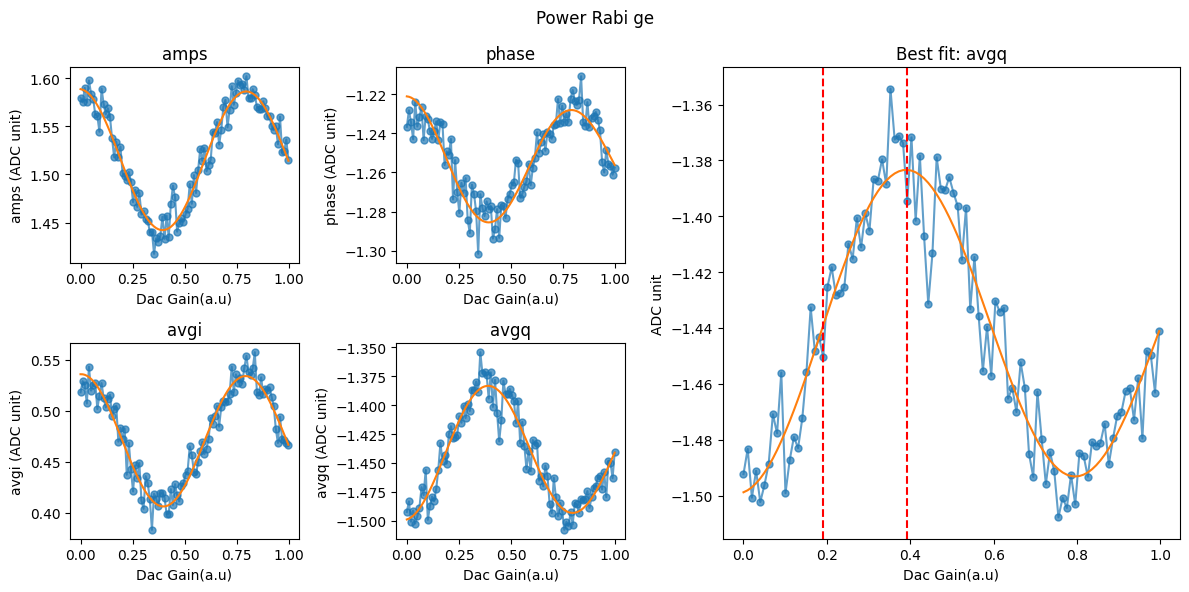

In [145]:
from qick_workspace.newscrip.s005_power_rabi_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ge", 0.02, q_index=qubit)
config_all.update("qb.nqz_qb", 1, q_index=qubit)
config_all.update("relax_delay", 200, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),

    ]
)

prabi = PowerRabi(soc, soccfg, run_cfg)
pi_gain, pi2_gain = prabi.run(20)
config_all.update("qb.pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("qb.pi2_gain_ge", pi2_gain, q_index=qubit)

In [126]:
prabi.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s005_power_rabi_ge_Q3_002


## Amplified Amplitude Error (AAE)

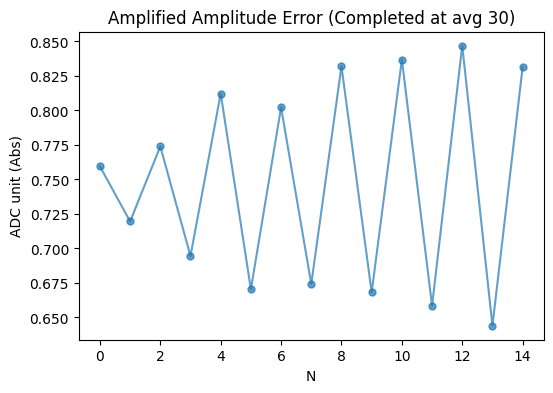

In [127]:
from qick_workspace.newscrip.s005a_AAE import AAE

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("AAE", "pi2"),

    ]
)

aae = AAE(soc, soccfg, run_cfg)
aae.run(30, iteration_count=15)

## Ramsey ge

Experiment interrupted at 13 averages. Fit is based on partial data.


(array([4.54696456e-02, 2.38217628e+00, 1.97415811e+02, 5.01580682e+00,
        6.23553351e-01]),
 array([4.21005105e-03, 7.85265752e-03, 5.17788539e+00, 1.27841055e+00,
        1.16130171e-03]))

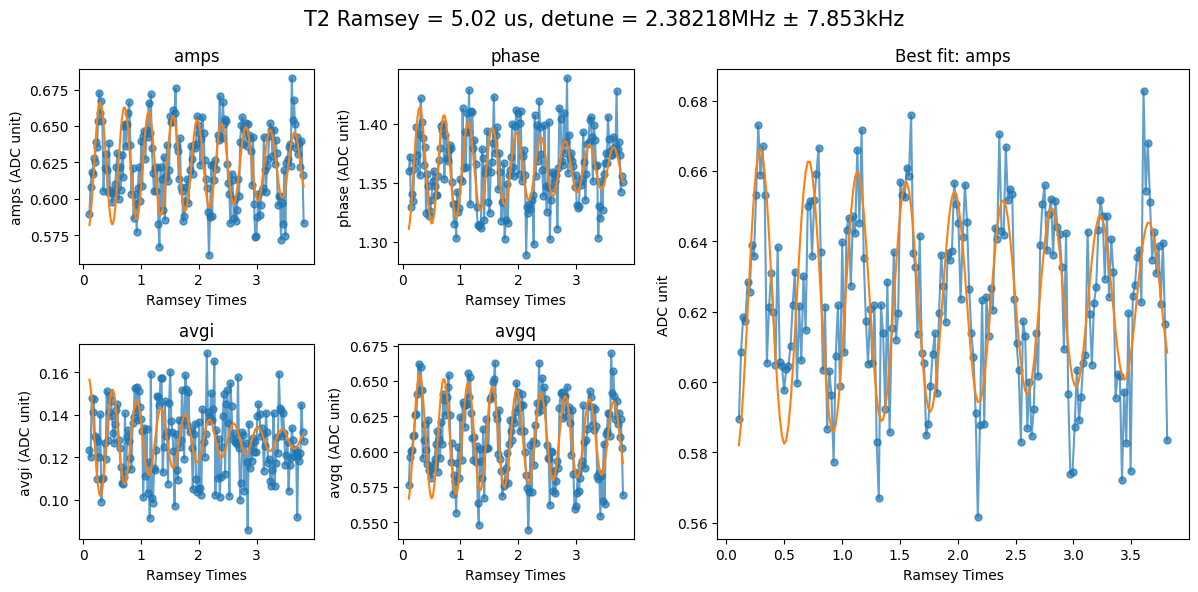

In [142]:
from qick_workspace.newscrip.s006_Ramsey_ge import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 4  # [us]
STEPS = 200
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
    ]
)

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(100)


In [143]:
config_all.update("qb.qb_freq_ge", t2r.correct_detune(), qubit)

over detune 0.38218MHz


In [118]:
t2r.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s006_Ramsey_ge_Q3_004


## Spin Echo ge

Experiment interrupted at 35 averages. Fit is based on partial data.


(array([ 4.55032765e-02,  5.03371553e-02,  2.62413585e+02,  9.78713684e+01,
        -2.16081927e-01]),
 array([3.24322282e-03, 2.37205789e-04, 4.33967755e+00, 1.36254585e+01,
        8.94579354e-04]))

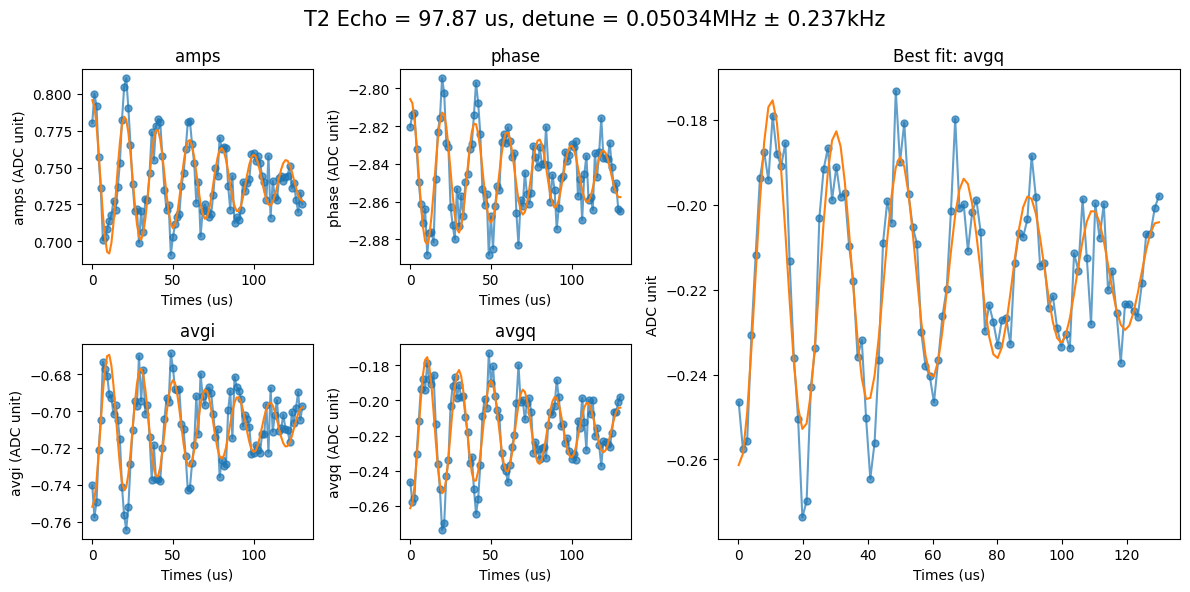

In [152]:
from qick_workspace.newscrip.s007_SpinEcho_ge import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 130  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 0.05),

    ]
)

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(100)

In [129]:
t2e.saveLabber(qubit,config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s007_SpinEcho_ge_Q3_005


## T1 ge

Experiment interrupted at 21 averages. Fit is based on partial data.


(array([  0.85205089,  -0.16758986, 110.62152768]),
 array([3.62576578e-03, 4.96183540e-03, 8.97481006e+00]))

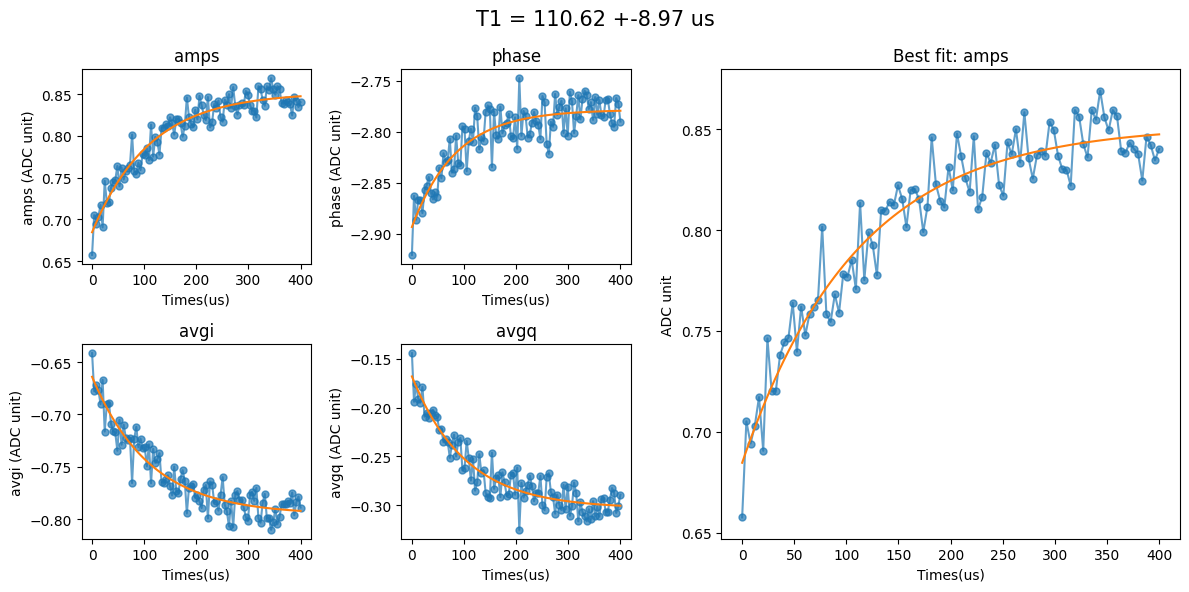

In [151]:
from qick_workspace.newscrip.s008_T1_ge import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 400  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 100),
        # ("cooling", False),
    ]
)

t1 = T1(soc, soccfg, run_cfg)
t1.run(100)

In [149]:
t1.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s008_T1_ge_Q4_001


## Single Shot

  0%|          | 0/5000 [00:00<?, ?it/s]

Attempted to init fitparam 3 to 0.0, which is out of bounds 0 to 92. Instead init to 46.0
Attempted to init fitparam 3 to 0.0, which is out of bounds 0 to 94. Instead init to 47.0


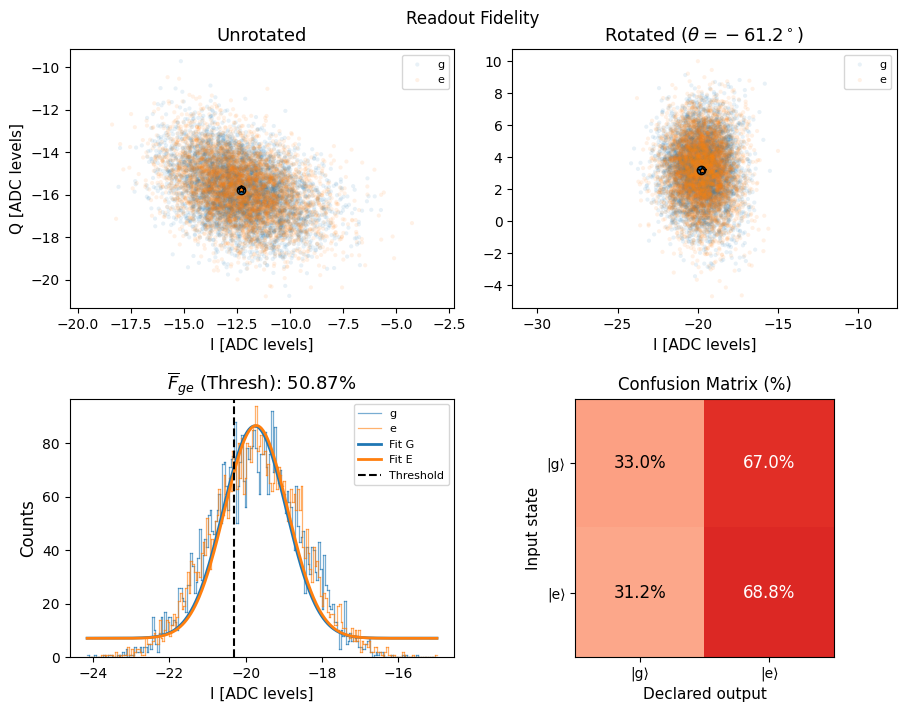

Theta: -61.20 deg
Threshold Fidelity: 50.870%
Confusion Matrix (%):
 [[32.96 67.04]
 [31.22 68.78]]


[[np.float64(0.5087)],
 [np.float64(-20.307165957349376)],
 np.float64(-61.196038074641415),
 [array([ 79.27606703, -19.76651814,   0.82518108,   7.11559415]),
  array([ 79.49687664, -19.72605395,   0.82518108,   7.06578005])],
 [array([[ 4.56364505e+00, -5.61160626e-09, -1.99463098e-02,
          -5.97240621e-01],
         [-5.61160626e-09,  5.98264159e-04,  2.02707946e-10,
          -6.51841418e-09],
         [-1.99463098e-02,  2.02707946e-10,  7.81286639e-04,
          -1.24332224e-02],
         [-5.97240621e-01, -6.51841418e-09, -1.24332224e-02,
           8.44623136e-01]]),
  array([[ 3.66339906e+00, -5.51815993e-09, -1.59671323e-02,
          -4.79426064e-01],
         [-5.51815993e-09,  4.77583650e-04,  1.41178142e-10,
          -3.79901144e-09],
         [-1.59671323e-02,  1.41178142e-10,  6.23687473e-04,
          -9.95287528e-03],
         [-4.79426064e-01, -3.79901144e-09, -9.95287528e-03,
           6.78009131e-01]])]]

In [33]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

run_cfg["ro_length"] = 1
run_cfg["res_gain_ge"] = 0.5

SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=False)
ssh.plot(fid_avg=True, verbose=True, fit=True)

# EF State

## Resonator OneTone ef

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.8888),
 'Qi': -12178,
 'Ql': -172,
 'absQc': -174,
 'κ(MHz)': np.float64(-40.06)}


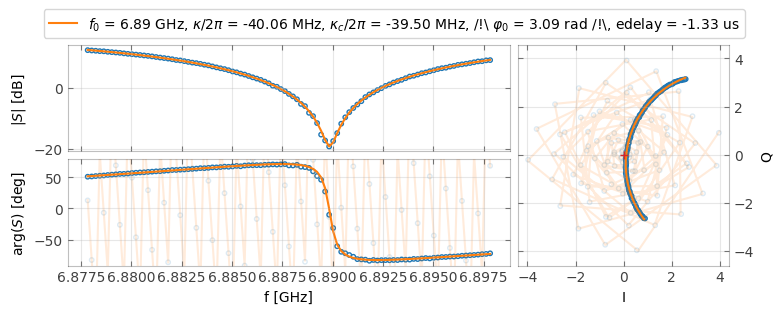

In [186]:
from qick_workspace.newscrip.s009_res_spec_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.5, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 100),
    ]
)

onetone_ef = ResonatorSpec_ef(soc, soccfg, run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

Experiment interrupted at 8 averages. Fit is based on partial data.


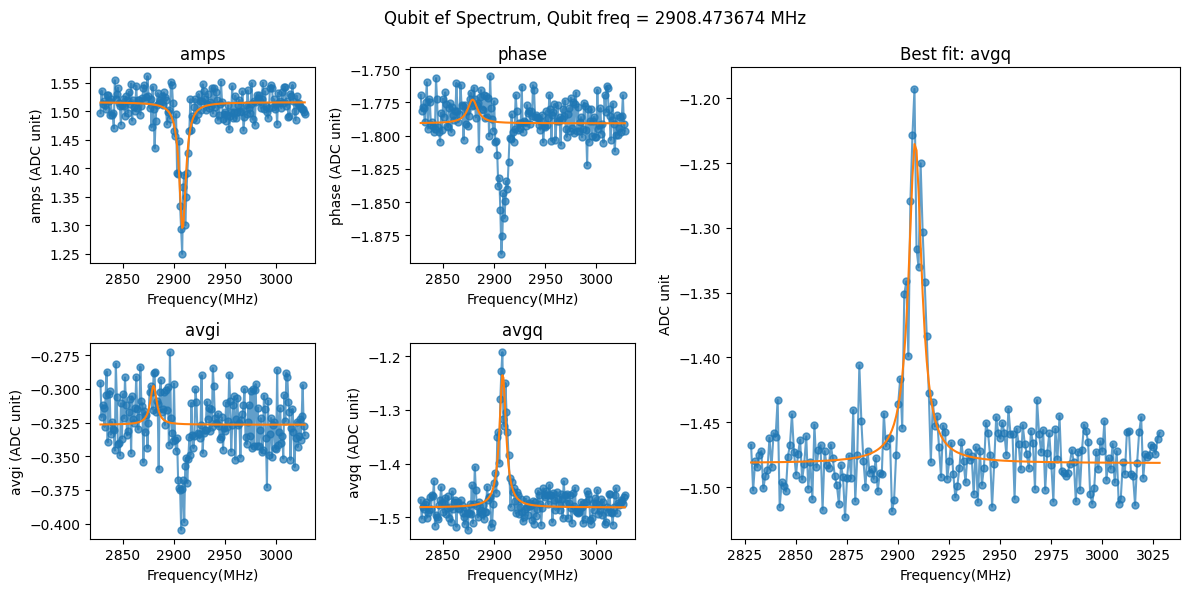

In [88]:
from qick_workspace.newscrip.s010_qubit_spec_ef import QubitSpec_ef

center = config_all.get_qubit(qubit)["qb_freq_ge"]-200
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201
config_all.update('ch.qb_ch_ef', 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.1),
        ("qb_flat_top_length_ef", 1),
        ("relax_delay", 50),
        ('ge_ref',True)

    ]
)

spectrum_ef = QubitSpec_ef(soc, soccfg, run_cfg)
f_ef = spectrum_ef.run(500)
config_all.update("qb.qb_freq_ef", f_ef, q_index=qubit)
config_all.update("qb.qb_mixer_ef", f_ef, q_index=qubit)
# spectrum_ef.saveLabber(qubit, yoko_value=yoko_value)

In [89]:
spectrum_ef.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s010_qubit_spec_ef_Q3_001


## Power Rabi ef

Experiment interrupted at 7 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s011_power_rabi_ef_Q3_002


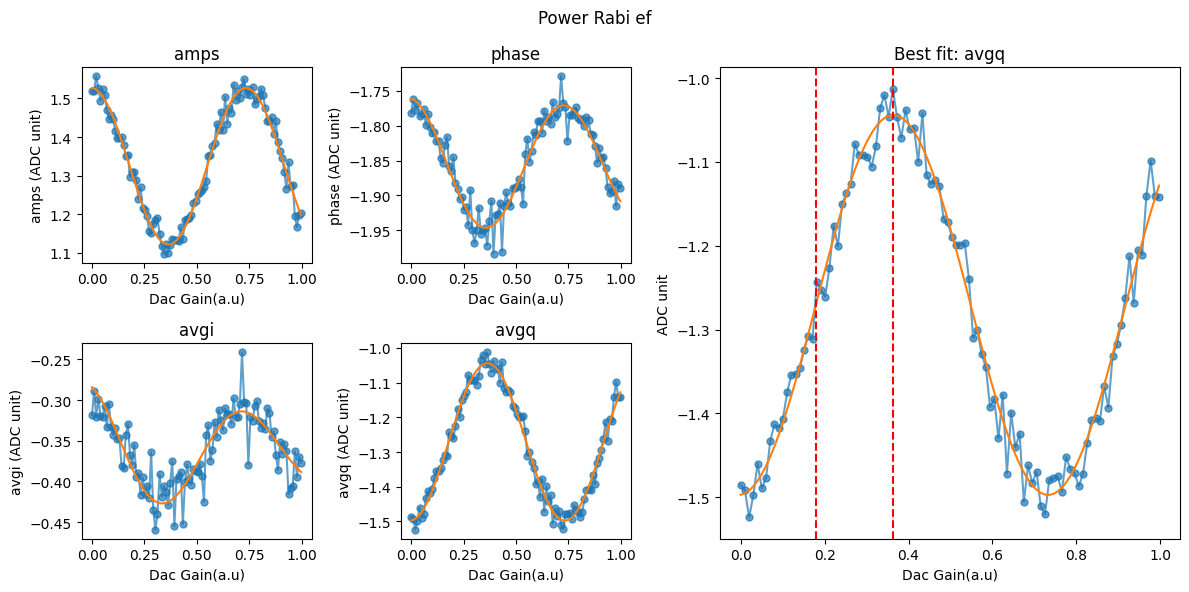

In [91]:
from qick_workspace.newscrip.s011_power_rabi_ef import PowerRabi_ef

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ef", 0.005, q_index=qubit)
config_all.update("relax_delay", 500, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ('ge_ref',True),

    ]
)

prabi_ef = PowerRabi_ef(soc, soccfg, run_cfg)
pi_gain_ef, pi2_gain_ef = prabi_ef.run(500)
config_all.update("qb.pi_gain_ef", pi_gain_ef, q_index=qubit)
config_all.update("qb.pi2_gain_ef", pi2_gain_ef, q_index=qubit)
prabi_ef.saveLabber(qubit, config_all=config_all)

[Temp] A_meas=0.0380  A_ref=0.1912  ratio=5.0313
[Temp] Estimated temperature: 92.92 mK


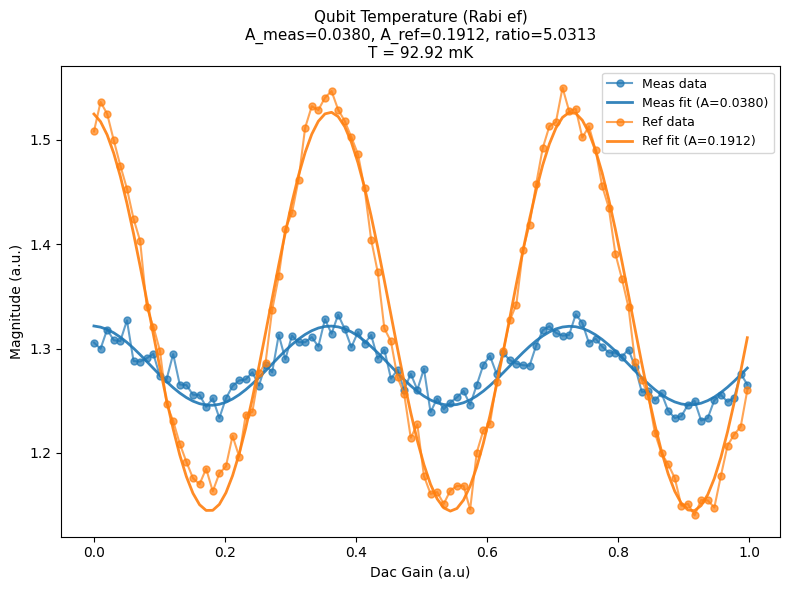

np.float64(0.0929189097492749)

In [98]:
from qick_workspace.newscrip.s013_qubit_temp import QubitTemperatureEf
START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ef", 0.01, q_index=qubit)
config_all.update("relax_delay", 200, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ('ge_ref', True),
        ("qb_ch_ef", 0),

    ]
)
rabi_temp= QubitTemperatureEf(soc, soccfg, run_cfg)
rabi_temp.run(30)

In [99]:
rabi_temp.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s013b_qubit_temp_ef_Q3_003


## Ramsey ef

Experiment interrupted at 9 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\still\2026\03\Data_0320\s012_Ramsey_ef_Q1_002


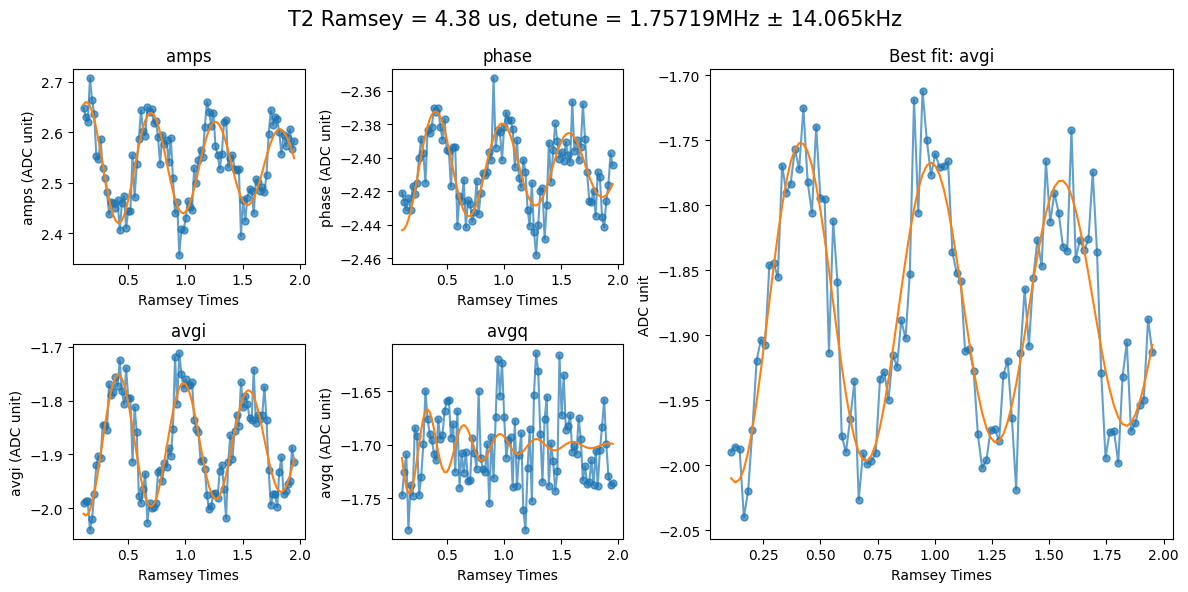

In [14]:
from qick_workspace.newscrip.s012_Ramsey_ef import Ramsey_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
        ('ge_ref', True),
        ('ro_length', 2)
    ]
)

t2r_ef = Ramsey_ef(soc, soccfg, run_cfg)
t2r_ef.run(100)
t2r_ef.saveLabber(qubit, config_all=config_all)

In [15]:
config_all.update("qb.qb_freq_ef", t2r_ef.correct_detune(), qubit)

over detune -0.24281MHz


## T1 ef

In [ ]:
from qick_workspace.newscrip.s013_T1_ef import T1_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 50  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 50),
        ("cooling", False),
    ]
)

t1_ef = T1_ef(soc, soccfg, run_cfg)
t1_ef.run(50)
# t1_ef.saveLabber(qubit, yoko_value=yoko_value)

## Single Shot gef

In [ ]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

run_cfg["ro_length"] = 0.4
run_cfg["res_gain_ge"] = 0.17341
run_cfg["res_freq_ge"] = 5352.28064
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True, fit=False)

# AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

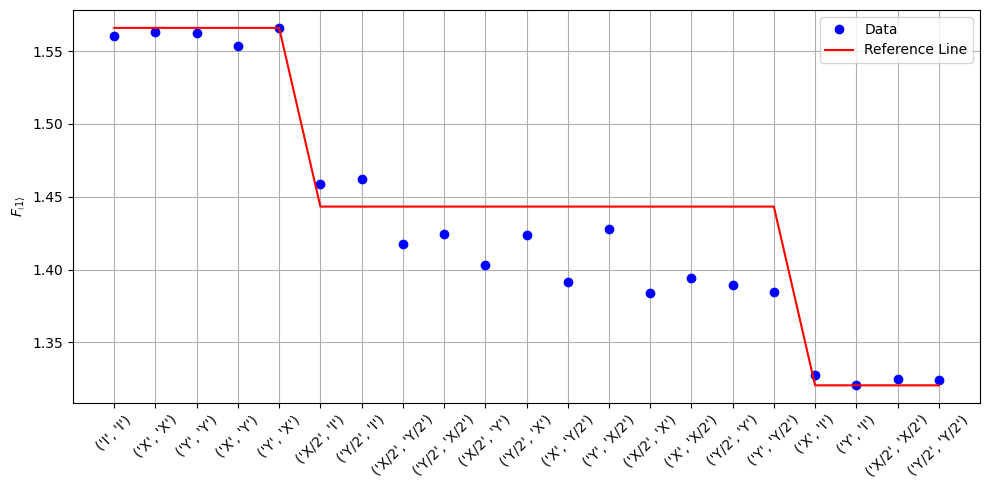

In [119]:
from qick_workspace.newscrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)

allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(50)
allxy.plot()

# State Tomography

Calibrating |0⟩ state...
Calibrating |1⟩ state...
IQ Ground: (-0.3548807942708333-1.5269724609375004j), IQ Excited: (-0.4595430989583334-1.2414113932291664j)


Tomography (x180):   0%|          | 0/3 [00:00<?, ?it/s]


<X>=-0.1776, <Y>=-0.3597, <Z>=-1.0000
Purity: 1.00000


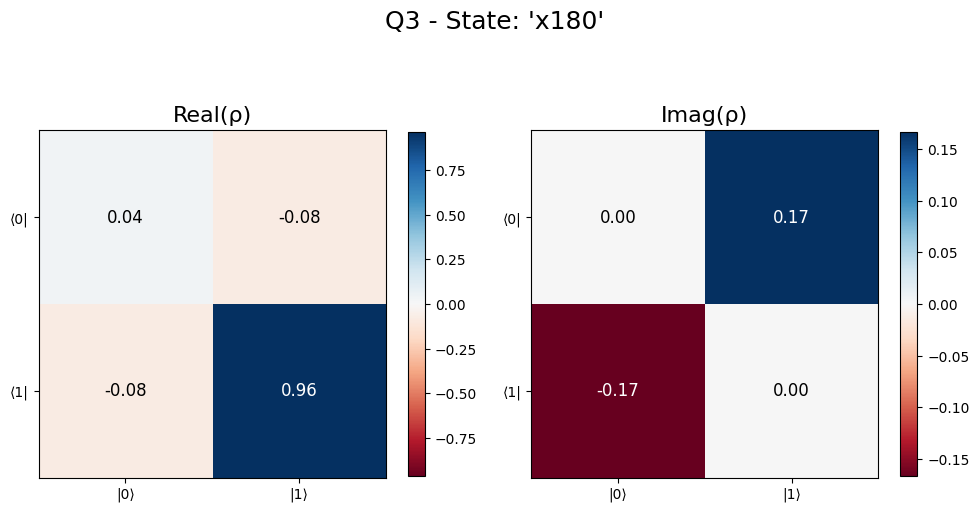

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\newscrip\s016_state_tomography.py:216: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


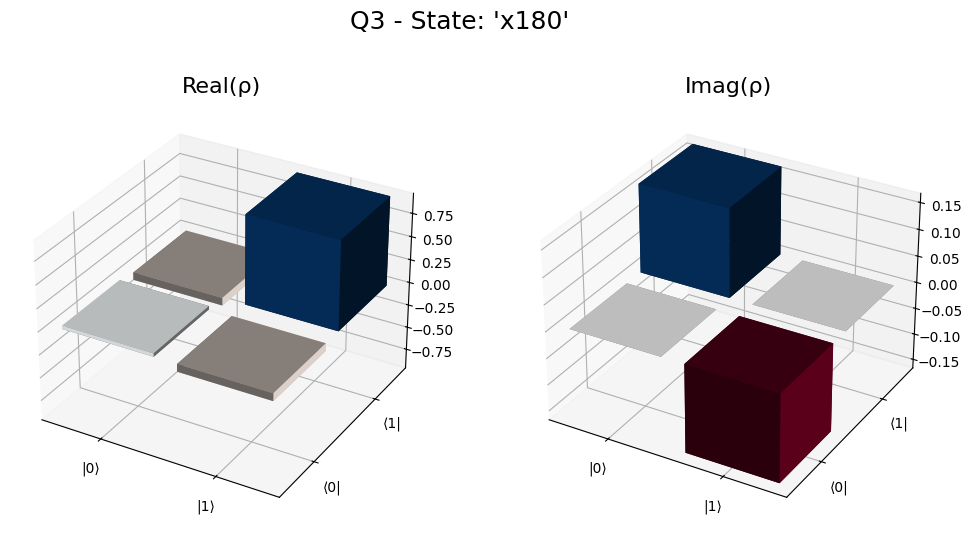

(<Figure size 1200x600 with 2 Axes>, None)

In [120]:
from qick_workspace.newscrip.s016_state_tomography import Tomography

pyavg = 100

run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(soc, soccfg, run_cfg)

tomo.run(py_avg=pyavg, prep_pulse_name="x180")

tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking


--- Running Standard RB (Ref) ---


Standard RB depth:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

[0.94356029 0.31322399 1.26424532]
0.00034986471400044814 0.001250181913485172 0.0013226571319582294

--- Ref ---
  p = 94.356029 ± 1.870467 %
  EPC = 2.821985 ± 0.935234 %


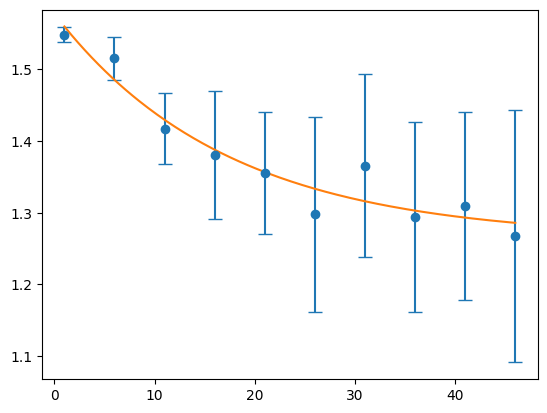

In [121]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)

py_avg = 30
max_circuit_depth = 50
delta_clifford = 5
number_sample = 10

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
    interleaved_gate=None,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)

## Interleaved RB

In [ ]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)


[DRAG Sum] Optimal α = 0.502701  (max=8.41, min=7.04)


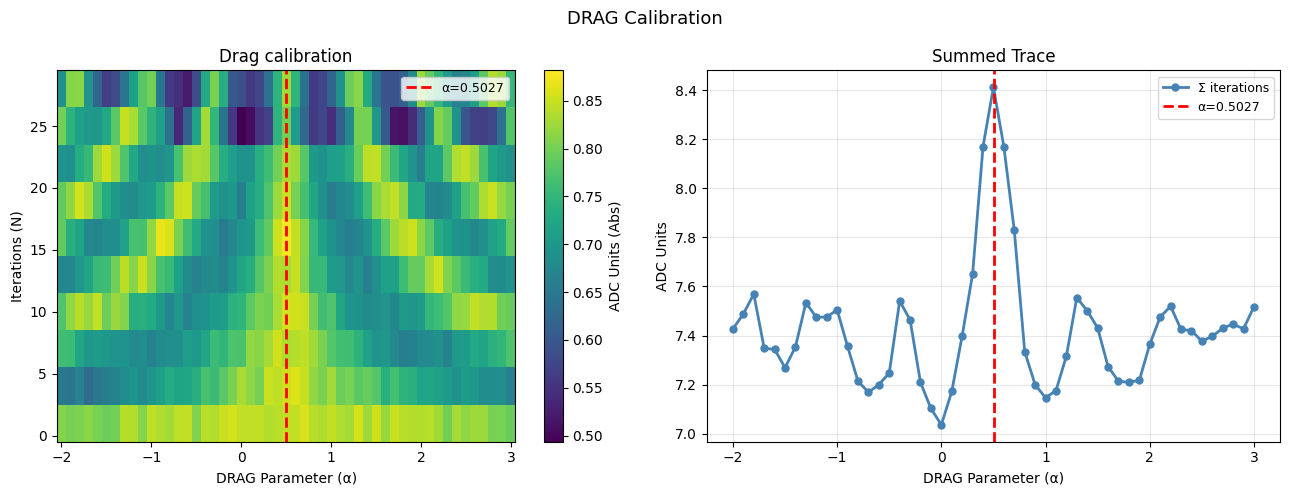

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0327\s005a_drag_ge_Q3_003


In [160]:
from qick_workspace.newscrip.s005a_drag import DragCalibration

config_all.update("relax_delay", 100, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        # alpha
        ("alpha_start", -2.0),
        ("alpha_stop", 3.0),
        ("alpha_steps", 51),
        # iteration
        ("iter_start", 1),
        ("iter_stop", 30),
        ("iter_step", 3),
    ]
)

drag_cal = DragCalibration(soc, soccfg, run_cfg)
opt_alpha = drag_cal.run(py_avg=20) 

if opt_alpha is not None:
    config_all.update("qb.drag_alpha", opt_alpha, q_index=qubit)

drag_cal.saveLabber(qubit, config_all=config_all)
